## Install TabPFN

In [1]:
!pip install -q -q --no-warn-conflicts tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00


## Ready Env

In [2]:
import os
from pathlib import Path

KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_RESULT_SUBDIR = "modeling_results"
is_kaggle_env = os.path.isdir("/kaggle/working")


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above cwd.")


def _discover_vlst_csv() -> Path:
    env = os.environ.get("VLST_RAW_CSV")
    if env and Path(env).is_file():
        return Path(env)
    for p in (
        Path(KAGGLE_RAW_CSV),
        Path("/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"),
        Path("/kaggle/input/vlst-data/VLST.csv"),
        Path("/kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv")
    ):
        if p.is_file():
            return p
    base = Path("/kaggle/input")
    if base.is_dir():
        for p in base.rglob("VLST.csv"):
            if p.is_file():
                return p
    raise FileNotFoundError(
        "VLST.csv not found. On Kaggle, add the vlst-data dataset or set VLST_RAW_CSV."
    )


def _resolve_paths():
    if is_kaggle_env:
        raw = _discover_vlst_csv()
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return raw, result, "Kaggle"
    repo = _find_repo_root()
    return (
        Path(os.environ.get("VLST_RAW_CSV", repo / "data" / "raw" / "VLST.csv")),
        Path(os.environ.get("VLST_RESULT_DIR", repo / "data" / "result" / "modeling_results")),
        "local",
    )

def _load_tabpfn_tokens():
    hf = os.environ.get("HF_TOKEN", "").strip()
    tabpfn = os.environ.get("TABPFN_TOKEN", "").strip()
    if tabpfn:
        return hf, tabpfn
    
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    hf = secrets.get_secret("HF_TOKEN")
    tabpfn = secrets.get_secret("TABPFN_TOKEN")
    return hf, tabpfn


RAW_PATH, RESULT_DIR, _runtime = _resolve_paths()
RESULT_DIR.mkdir(parents=True, exist_ok=True)

try:
    import torch

    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"

_hf_token, _tabpfn_token = _load_tabpfn_tokens()
if _tabpfn_token:
    os.environ["TABPFN_TOKEN"] = _tabpfn_token
if _hf_token:
    os.environ["HF_TOKEN"] = _hf_token

print("Runtime:", _runtime)
print("RAW_PATH:", RAW_PATH)
print("RESULT_DIR:", RESULT_DIR)
print("CUDA:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE)
print("are TOKENs ready:", bool(_tabpfn_token) and bool(_hf_token))

Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv
RESULT_DIR: /kaggle/working/modeling_results
CUDA: True | Tesla T4
CatBoost: GPU | XGB: cuda
are TOKENs ready: True


## Fit and Eval

Running nested 4-fold outer / 3-fold inner CV...
Processing outer fold 1/4...
  Logistic Regression: estimating threshold from inner OOF predictions
  Random Forest: estimating threshold from inner OOF predictions
  XGBoost: estimating threshold from inner OOF predictions
  LightGBM: estimating threshold from inner OOF predictions
  CatBoost: estimating threshold from inner OOF predictions
  TabPFN: estimating threshold from inner OOF predictions


Found existing access token, reusing it for authentication.

03:01 Fitting... Done!
00:09 Predicting... Done!
03:46 Fitting... Done!
00:15 Predicting... Done!
02:51 Fitting... Done!
00:08 Predicting... Done!
03:16 Fitting... Done!
00:09 Predicting... Done!
Processing outer fold 2/4...
  Logistic Regression: estimating threshold from inner OOF predictions
  Random Forest: estimating threshold from inner OOF predictions
  XGBoost: estimating threshold from inner OOF predictions
  LightGBM: estimating threshold from inner OOF predictions
  CatBoost: estimating threshold from inner OOF predictions
  TabPFN: estimating threshold from inner OOF predictions
02:56 Fitting... Done!
00:10 Predicting... Done!
02:56 Fitting... Done!
00:09 Predicting... Done!
03:11 Fitting... Done!
00:08 Predicting... Done!
05:22 Fitting... Done!
00:19 Predicting... Done!
Processing outer fold 3/4...
  Logistic Regression: estimating threshold from inner OOF predictions
  Random Forest: estimating threshold from inner OOF predictions
  XGBoost: estimating threshold from inne

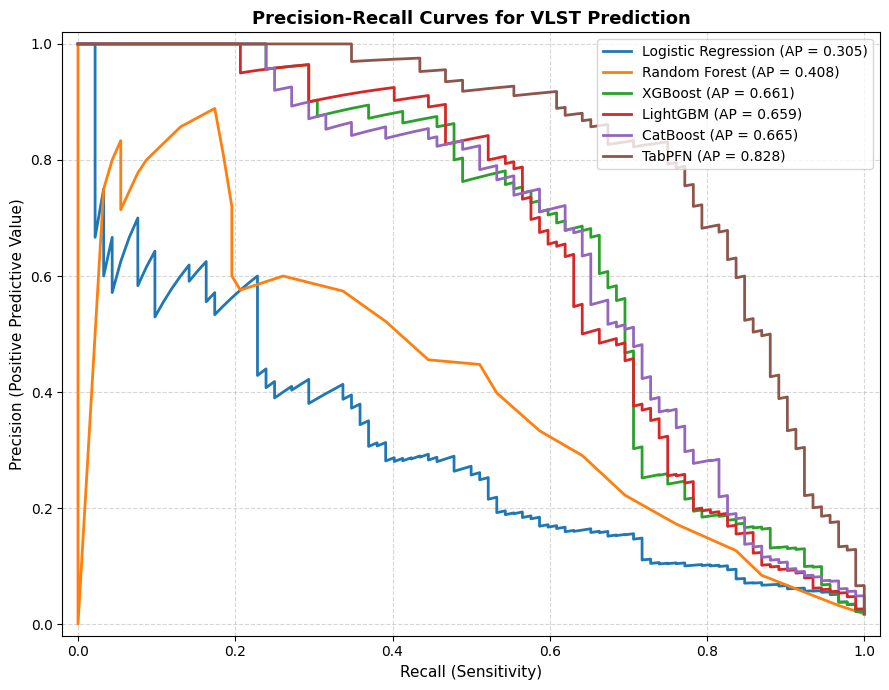

Saved precision-recall curves to: /kaggle/working/modeling_results/vlst_pr_curves.png

=== NESTED-CV MODEL COMPARISON ===
              Model Threshold mean±SD Average Precision ROC-AUC F1-Score Accuracy Precision Recall
Logistic Regression       0.903±0.094            0.3046  0.9201   0.3652   0.9718    0.3043 0.4565
      Random Forest       0.090±0.008            0.4085  0.9239   0.4722   0.9780    0.4113 0.5543
            XGBoost       0.251±0.131            0.6612  0.9557   0.6590   0.9886    0.7037 0.6196
           LightGBM       0.173±0.130            0.6589  0.9557   0.6215   0.9871    0.6471 0.5978
           CatBoost       0.341±0.148            0.6645  0.9650   0.5699   0.9846    0.5638 0.5761
             TabPFN       0.922±0.022            0.8277  0.9888   0.7717   0.9919    0.7717 0.7717

=== CONFUSION MATRICES (Fold-Specific Inner-CV Thresholds) ===

Logistic Regression:
  TN: 4997  FP: 96
  FN: 50    TP: 42

Random Forest:
  TN: 5020  FP: 73
  FN: 41    TP: 51

XGBoos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve
)

# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# TabPFN
from tabpfn_client import TabPFNClassifier

# 1. Load and validate data
df = pd.read_csv(RAW_PATH)
TARGET = "Stent thrombosis"
X = df.drop(columns=["NO.", "Name", "Time since stent implantation", TARGET], errors="ignore")
y = df[TARGET].astype(int)
if set(y.unique()) != {0, 1}:
    raise ValueError(f"{TARGET!r} must contain exactly the binary labels 0 and 1.")

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()
if len(numeric_features) + len(categorical_features) != X.shape[1]:
    unsupported = sorted(set(X.columns) - set(numeric_features) - set(categorical_features))
    raise TypeError(f"Unsupported feature dtypes for columns: {unsupported}")

# 2. Preprocessing is cloned and fitted independently inside every CV split.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
]).set_output(transform="pandas")


def lightgbm_safe_frame(data):
    """Use stable feature names accepted by LightGBM's JSON model format."""
    frame = data.copy() if isinstance(data, pd.DataFrame) else pd.DataFrame(data)
    frame.columns = [f"feature_{index}" for index in range(frame.shape[1])]
    return frame


# 3. Model templates. Average precision (PR-AUC) is the common metric.
# LogisticRegression and RandomForestClassifier have no internal eval_metric;
# both are evaluated with average_precision_score on outer OOF predictions.
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", XGBClassifier(random_state=42, eval_metric="aucpr"))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("safe_feature_names", FunctionTransformer(lightgbm_safe_frame, validate=False)),
        ("clf", LGBMClassifier(
            class_weight="balanced",
            metric="average_precision",
            random_state=42,
            verbose=-1,
        ))
    ]),
    "CatBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", CatBoostClassifier(
            auto_class_weights="Balanced",
            eval_metric="PRAUC",
            random_state=42,
            verbose=0,
        ))
    ]),
    "TabPFN": TabPFNClassifier(
        balance_probabilities=True,
        thinking_mode=True,
        thinking_effort="high",
        thinking_metric="average_precision",
        random_state=42
    )
}


def fresh_model(model_name, model_template, y_fit):
    """Clone a model and derive label-dependent settings from training data only."""
    model = clone(model_template)
    if model_name == "XGBoost":
        n_positive = int((y_fit == 1).sum())
        n_negative = int((y_fit == 0).sum())
        if n_positive == 0:
            raise ValueError("XGBoost training split contains no positive cases.")
        model.set_params(clf__scale_pos_weight=n_negative / n_positive)
    return model


def optimal_f1_threshold(y_true, probabilities):
    """Choose an F1 threshold using only the supplied calibration labels."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, probabilities)
    if thresholds.size == 0:
        return 0.5
    f1_values = (
        2 * precisions[:-1] * recalls[:-1]
        / (precisions[:-1] + recalls[:-1] + 1e-10)
    )
    return float(thresholds[int(np.argmax(f1_values))])


# 4. Nested CV: tune thresholds on inner OOF predictions and apply each
# threshold once to that outer fold's unseen validation cases.
OUTER_SPLITS = 4
INNER_SPLITS = 3
outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=42)
oof_probabilities = {name: np.zeros(len(X), dtype=float) for name in models}
oof_binary_predictions = {name: np.zeros(len(X), dtype=int) for name in models}
fold_thresholds = {name: [] for name in models}

print(f"Running nested {OUTER_SPLITS}-fold outer / {INNER_SPLITS}-fold inner CV...")
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Processing outer fold {outer_fold}/{OUTER_SPLITS}...")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val = X.iloc[val_idx]
    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=10_000 + outer_fold,
    )

    for model_name, model_template in models.items():
        print(f"  {model_name}: estimating threshold from inner OOF predictions")
        inner_oof_probabilities = np.zeros(len(X_train), dtype=float)
        for inner_train_idx, calibration_idx in inner_cv.split(X_train, y_train):
            X_inner_train = X_train.iloc[inner_train_idx]
            y_inner_train = y_train.iloc[inner_train_idx]
            X_calibration = X_train.iloc[calibration_idx]
            inner_model = fresh_model(model_name, model_template, y_inner_train)
            inner_model.fit(X_inner_train, y_inner_train)
            inner_oof_probabilities[calibration_idx] = inner_model.predict_proba(X_calibration)[:, 1]

        fold_threshold = optimal_f1_threshold(y_train, inner_oof_probabilities)
        fold_thresholds[model_name].append(fold_threshold)
        outer_model = fresh_model(model_name, model_template, y_train)
        outer_model.fit(X_train, y_train)
        val_probabilities = outer_model.predict_proba(X_val)[:, 1]
        oof_probabilities[model_name][val_idx] = val_probabilities
        oof_binary_predictions[model_name][val_idx] = (
            val_probabilities >= fold_threshold
        ).astype(int)

# 5. Aggregate honest outer-fold probabilities and binary decisions.
report_data = []
confusion_matrices = {}
plt.figure(figsize=(9, 7))
for model_name, probabilities in oof_probabilities.items():
    binary_predictions = oof_binary_predictions[model_name]
    thresholds_used = np.asarray(fold_thresholds[model_name])
    precisions, recalls, _ = precision_recall_curve(y, probabilities)
    average_precision = average_precision_score(y, probabilities)
    roc_auc = roc_auc_score(y, probabilities)
    f1 = f1_score(y, binary_predictions)
    acc = accuracy_score(y, binary_predictions)
    prec = precision_score(y, binary_predictions, zero_division=0)
    rec = recall_score(y, binary_predictions, zero_division=0)
    cm = confusion_matrix(y, binary_predictions, labels=[0, 1])
    confusion_matrices[model_name] = cm
    report_data.append({
        "Model": model_name,
        "Threshold mean±SD": f"{thresholds_used.mean():.3f}±{thresholds_used.std(ddof=1):.3f}",
        "Average Precision": f"{average_precision:.4f}",
        "ROC-AUC": f"{roc_auc:.4f}",
        "F1-Score": f"{f1:.4f}",
        "Accuracy": f"{acc:.4f}",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}"
    })
    plt.plot(
        recalls,
        precisions,
        label=f"{model_name} (AP = {average_precision:.3f})",
        lw=2,
    )

# 6. Save the precision-recall figure to the resolved results directory.
plt.xlabel("Recall (Sensitivity)", fontsize=11)
plt.ylabel("Precision (Positive Predictive Value)", fontsize=11)
plt.title("Precision-Recall Curves for VLST Prediction", fontsize=13, fontweight="bold")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
figure_path = RESULT_DIR / "vlst_pr_curves.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved precision-recall curves to: {figure_path}")

# 7. Publication tables based only on outer-fold predictions.
df_report = pd.DataFrame(report_data)
print("\n=== NESTED-CV MODEL COMPARISON ===")
print(df_report.to_string(index=False))
print("\n=== CONFUSION MATRICES (Fold-Specific Inner-CV Thresholds) ===")
for model_name, cm in confusion_matrices.items():
    print(f"\n{model_name}:")
    print(f"  TN: {cm[0, 0]:<5} FP: {cm[0, 1]}")
    print(f"  FN: {cm[1, 0]:<5} TP: {cm[1, 1]}")